<a href="https://colab.research.google.com/github/eykaryeli/Physics-Simulations-with-Python/blob/main/04_Free_Fall_and_Sensor_Noise/free_fall_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

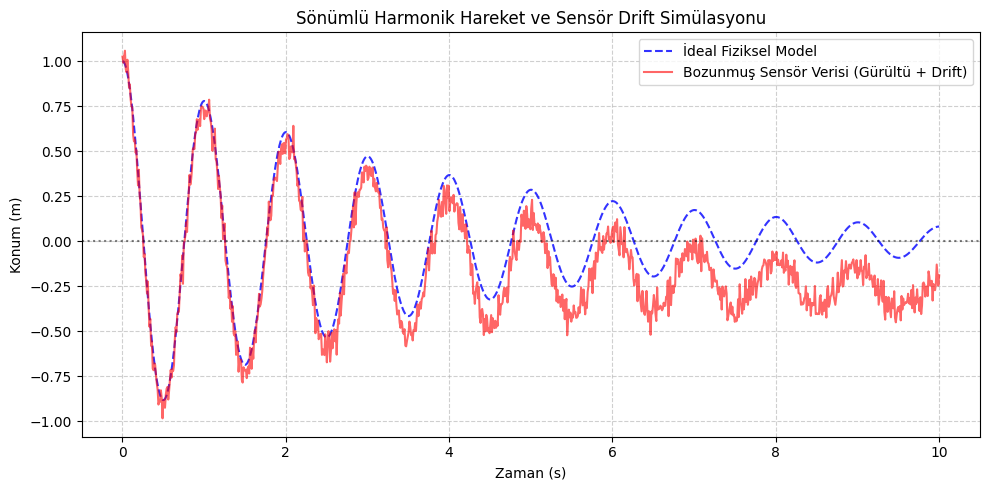

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# --- 1. FİZİKSEL SİSTEM MİMARİSİ (Sönümlü Harmonik Salınıcı) ---
# Denklem: d²x/dt² + 2γ(dx/dt) + ω₀²x = 0
omega_0 = 2.0 * np.pi  # Doğal frekans (1 Hz)
gamma = 0.25  # Sönüm katsayısı (Hava direnci / Sürtünme)


def harmonic_oscillator(t, y):
    x, v = y  # y = [konum, hız] durum dizisini bileşenlerine ayırıyoruz
    dxdt = v  # Konumun zamana göre türevi = Hız
    dvdt = -2 * gamma * v - (omega_0**2) * x  # Hızın zamana göre türevi = İvme
    return [dxdt, dvdt]  # Türevleri çözücüye geri döndürüyoruz


# Başlangıç Koşulları ve Zaman Aralığı
x0, v0 = 1.0, 0.0  # t=0 anında: Konum = 1m, Hız = 0 m/s
t_span = (0, 10)  # Simülasyon zamanı: 0 - 10 saniye
t_eval = np.linspace(0, 10, 1000)  # Grafik için 1000 pürüzsüz zaman adımı

# SciPy ile Diferansiyel Denklem Çözümü (Runge-Kutta 45 Yöntemi)
sol = solve_ivp(
    harmonic_oscillator, t_span, [x0, v0], t_eval=t_eval, method="RK45"
)

# --- 2. SENSÖR GÜRÜLTÜSÜ VE DRIFT SİMÜLASYONU ---
np.random.seed(42)  # Rastgele sayı üretecini sabitleme
ideal_signal = sol.y[0]  # Çözümden elde edilen kusursuz fiziksel konum verisi

# Sensör Hatalarının Oluşturulması
gaussian_noise = np.random.normal(
    0, 0.05, len(t_eval)
)  # Anlık rastgele titreşimler (Gürültü)
linear_drift = -0.03 * t_eval  # Zamana bağlı kademeli kayma (Sensör Yaşlanması)

# Gerçek Sensör Verisi (İdeal Sinyal + Gürültü + Kayma)
sensor_signal = ideal_signal + gaussian_noise + linear_drift

# --- 3. GÖRSELLEŞTİRME (Matplotlib) ---
plt.figure(figsize=(10, 5))
plt.plot(t_eval, ideal_signal, "b--", label="İdeal Fiziksel Model", alpha=0.8)
plt.plot(
    t_eval,
    sensor_signal,
    "r-",
    label="Bozunmuş Sensör Verisi (Gürültü + Drift)",
    alpha=0.6,
)

plt.title("Sönümlü Harmonik Hareket ve Sensör Drift Simülasyonu")
plt.xlabel("Zaman (s)")
plt.ylabel("Konum (m)")
plt.axhline(0, color="black", linestyle=":", alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

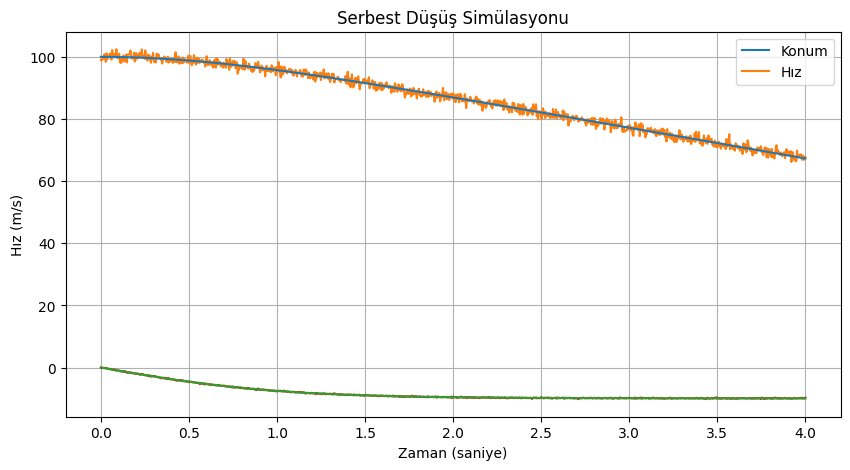

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
k = 0.1
m = 1.0

def havali_dusus (t , y):
  x , v = y
  dxdt = v
  dvdt = -9.81 + (k / m) * (v**2)
  return [dxdt,dvdt]
x0 = 100.0
v0 = 0
t_span = (0,4)
t_eval = np.linspace(0,4,1000)
sol = solve_ivp(havali_dusus , (0, 4), [x0, v0], t_eval=t_eval)
ideal_konum = sol.y[0]
ideal_hiz = sol.y[1]

gurultu = np.random.normal(0, 1.0, len(ideal_konum))
gurultulu_konum = ideal_konum + gurultu
gurultu_hiz = np.random.normal(0, 0.1, len(ideal_hiz))
gurultulu_hiz = ideal_hiz + gurultu_hiz
plt.figure(figsize=(10, 5))
plt.plot(sol.t , ideal_konum , zorder = 5)
plt.plot(sol.t , gurultulu_konum)
plt.ylabel("Konum (m)")
plt.plot(sol.t , ideal_hiz, zorder = 5)
plt.plot(sol.t , gurultulu_hiz)
plt.ylabel("Hız (m/s)")
plt.xlabel("Zaman (saniye)")
plt.title("Serbest Düşüş Simülasyonu")
plt.legend(["Konum", "Hız"])
plt.grid(True)
plt.show()


